In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/nlp-getting-started/sample_submission.csv
/kaggle/input/competitions/nlp-getting-started/train.csv
/kaggle/input/competitions/nlp-getting-started/test.csv


# Natural Language Processing with Disaster Tweets
## Kaggle Competition | My First NLP Project

**Author:** Muskan Gait  
**Competition:** [Disaster Tweets](https://www.kaggle.com/c/nlp-getting-started)  
**Public Leaderboard Score:** 0.79037  
**Metric:** F1 Score  

---

This is my first machine learning project. I am a beginner learning 
AI and ML from scratch. In this notebook I built a complete NLP 
pipeline to predict whether a tweet is about a real disaster or not.

### What I built
- Exploratory Data Analysis to understand the dataset
- Text preprocessing pipeline with 7 cleaning steps
- TF-IDF vectorization with 5000 features
- Trained 3 models and compared their performance
- Generated predictions and submitted to Kaggle

### Key Result
Naive Bayes gave the best F1 score of 0.8100 on validation 
and 0.79037 on the public leaderboard.

In [2]:

# CELL 1 — Imports

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print(" Libraries ready")

 Libraries ready


In [3]:
# CORRECT - matches your actual path
train = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/test.csv')
sub   = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/sample_submission.csv')
print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")
print(f"Sub   : {sub.shape}")
train.head(3)

Train : (7613, 5)
Test  : (3263, 4)
Sub   : (3263, 2)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1


## Step 1 — Exploratory Data Analysis

Before writing any model I first tried to understand the data.
I learned that you should never touch your data without understanding 
it first.

Key findings I discovered:
- 7613 training tweets with 57% not disaster and 43% disaster
- location column was 33% missing and too noisy to use
- Disaster tweets are longer on average (108 chars vs 95)
- Same keyword like "ablaze" appeared in both disaster and 
  non-disaster tweets — this showed me keyword alone is not enough

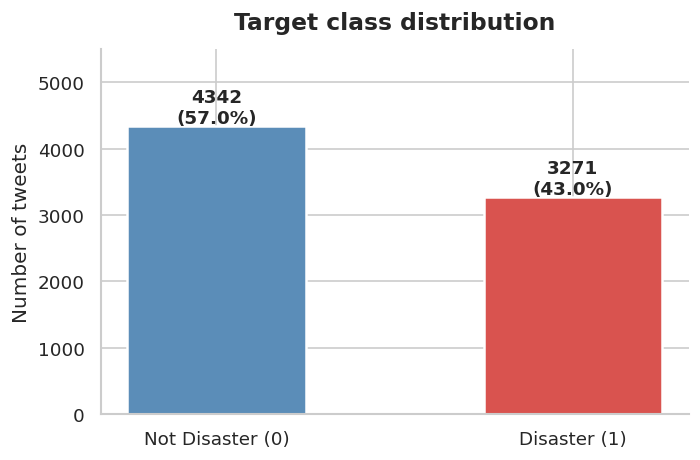


Class counts:
target
0    4342
1    3271
Name: count, dtype: int64

Class percentages:
target
0    57.0
1    43.0
Name: proportion, dtype: float64


In [4]:

# CELL 3 — Class balance

counts = train['target'].value_counts()
pcts   = train['target'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Not Disaster (0)', 'Disaster (1)'],
              counts.values,
              color=['#5B8DB8', '#D9534F'],
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, count, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 40,
            f'{count}\n({pct}%)',
            ha='center', fontweight='bold', fontsize=11)
ax.set_title('Target class distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of tweets')
ax.set_ylim(0, 5500)
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nClass counts:\n{counts}")
print(f"\nClass percentages:\n{pcts}")

## Step 2 — Text Preprocessing

Raw tweets are very noisy. I built a 7 step cleaning pipeline.

The biggest thing I learned here is that nearly 44% of every 
tweet is just noise — URLs, stopwords, punctuation, mentions.
Removing that noise made the actual signal much clearer for the model.

Steps:
1. Remove URLs
2. Decode HTML entities like &amp;
3. Lowercase everything
4. Remove mentions and hashtag symbols
5. Remove stopwords
6. Tokenize
7. Stem with PorterStemmer

In [5]:

missing     = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing count' : missing,
    'Missing %'     : missing_pct
})
print(missing_df)

print("\nMissing data visual:")
for col, pct in missing_pct.items():
    filled = '1' * int(pct / 2)
    empty  = '2' * (25 - int(pct / 2))
    print(f"  {col:<12} {filled}{empty}  {pct:.1f}%")

          Missing count  Missing %
id                    0       0.00
keyword              61       0.80
location           2533      33.27
text                  0       0.00
target                0       0.00

Missing data visual:
  id           2222222222222222222222222  0.0%
  keyword      2222222222222222222222222  0.8%
  location     1111111111111111222222222  33.3%
  text         2222222222222222222222222  0.0%
  target       2222222222222222222222222  0.0%


## Step 3 — Feature Engineering

The model cannot read text. It only understands numbers.
TF-IDF converts each tweet into a vector of numbers where 
high values mean that word is important for this specific tweet
but rare across all tweets.

Something interesting I discovered — I added 3 extra features
from EDA (character count, word count, average word length)
because disaster tweets tend to be longer and use longer words.
This brought total features from 5000 to 5003.

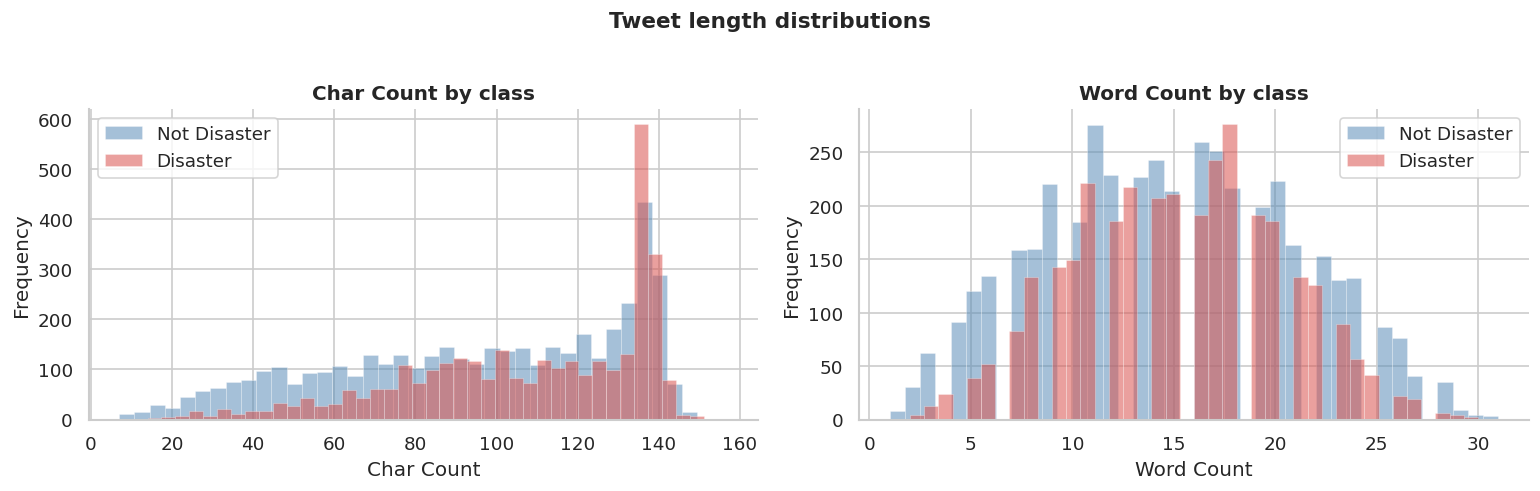


Mean values by class:
        char_count  word_count  avg_word_len
target                                      
0            95.71       14.70          6.79
1           108.11       15.17          7.40


In [6]:

# CELL 5 — Tweet length features

train['char_count']   = train['text'].str.len()
train['word_count']   = train['text'].str.split().str.len()
train['avg_word_len'] = (train['char_count'] / train['word_count']).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels = {0: 'Not Disaster', 1: 'Disaster'}
colors = {0: '#5B8DB8',      1: '#D9534F'}

for i, col in enumerate(['char_count', 'word_count']):
    ax = axes[i]
    for target in [0, 1]:
        data = train[train['target'] == target][col]
        ax.hist(data, bins=40, alpha=0.55,
                color=colors[target], label=labels[target],
                edgecolor='white', linewidth=0.3)
    ax.set_title(f'{col.replace("_", " ").title()} by class',
                 fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.legend()
    sns.despine(ax=ax)

plt.suptitle('Tweet length distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nMean values by class:")
print(train.groupby('target')[['char_count', 'word_count', 'avg_word_len']].mean().round(2))

## Step 4 — Model Building

I trained 3 models starting simple and increasing complexity.
This is industry standard — always start simple.

I was surprised that Naive Bayes beat Logistic Regression.
After reading about it I understood why — Naive Bayes was 
literally designed for text classification problems like this one.

Results on validation set:
| Model | F1 Score |
|-------|----------|
| Logistic Regression | 0.7914 |
| Naive Bayes | 0.8100 ← best |
| Random Forest | 0.7735 |

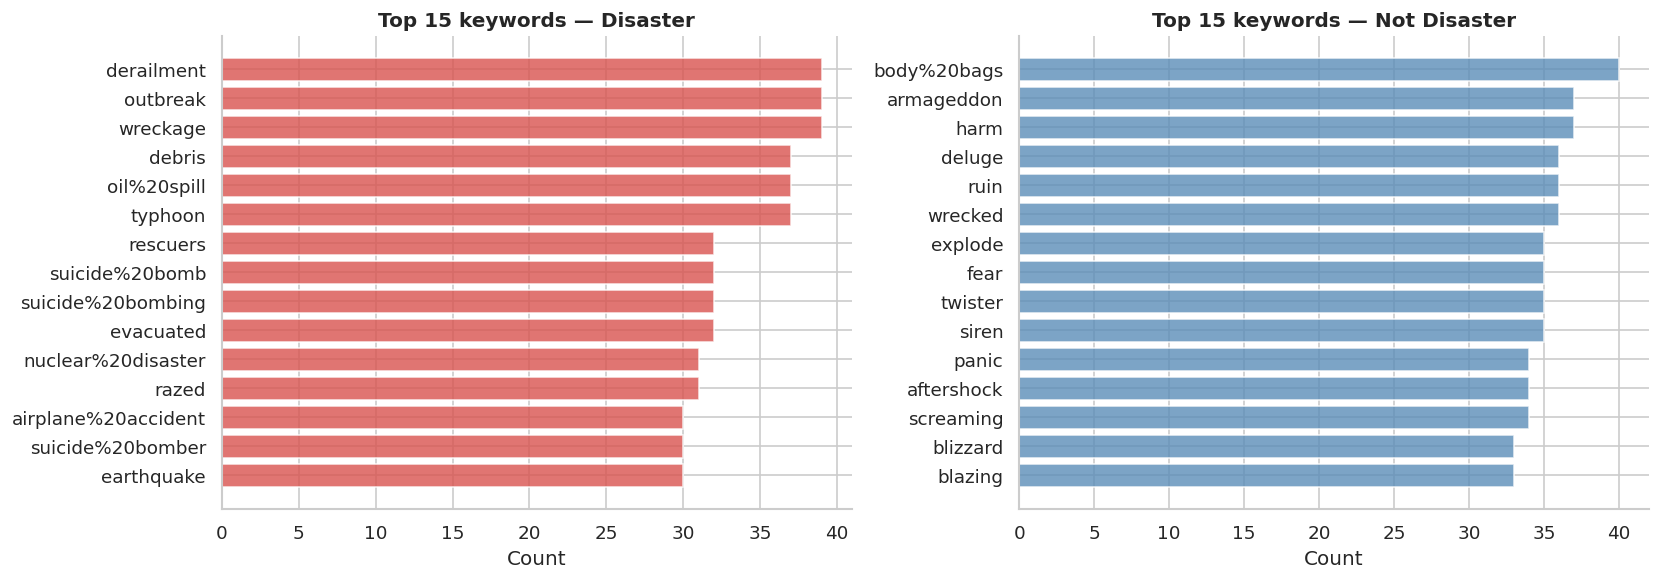

 Top 10 Disaster Keywords 
keyword
derailment           39
outbreak             39
wreckage             39
debris               37
oil%20spill          37
typhoon              37
rescuers             32
suicide%20bomb       32
suicide%20bombing    32
evacuated            32
Name: count, dtype: int64

 Top 10 Non-Disaster Keywords 
keyword
body%20bags    40
armageddon     37
harm           37
deluge         36
ruin           36
wrecked        36
explode        35
fear           35
twister        35
siren          35
Name: count, dtype: int64


In [7]:

# CELL 6 — Keyword analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target, title, color in zip(
    axes, [1, 0],
    ['Top 15 keywords — Disaster', 'Top 15 keywords — Not Disaster'],
    ['#D9534F', '#5B8DB8']
):
    data = (train[train['target'] == target]['keyword']
            .value_counts()
            .head(15))
    ax.barh(data.index[::-1], data.values[::-1], color=color, alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


print(" Top 10 Disaster Keywords ")
print(train[train['target']==1]['keyword'].value_counts().head(10))

print("\n Top 10 Non-Disaster Keywords ")
print(train[train['target']==0]['keyword'].value_counts().head(10))

## Step 5 — Submission

Used Naive Bayes (best model) to generate predictions on test data.
Public leaderboard score: **0.79037**

The validation score was 0.8100 and public score is 0.7904.
The small difference means the model generalizes well — no overfitting.

### What I would improve next
- Try lemmatization instead of stemming
- Add URL presence as a binary feature
- Try SVM which works well on text classification
- Tune TF-IDF parameters with GridSearchCV

In [8]:

# CELL 7 — Sample tweet inspection

print("=" * 70)
print("REAL DISASTER TWEETS (target = 1)")
print("=" * 70)
for i, tweet in enumerate(
    train[train['target']==1]['text'].sample(5, random_state=42), 1):
    print(f"\n[{i}] {tweet}")

print("\n" + "=" * 70)
print("NON-DISASTER TWEETS (target = 0)")
print("=" * 70)
for i, tweet in enumerate(
    train[train['target']==0]['text'].sample(5, random_state=42), 1):
    print(f"\n[{i}] {tweet}")

# Bonus — find tweets where same keyword appears in both classes
print("\n" + "=" * 70)
print("SAME KEYWORD — DIFFERENT MEANING (ablaze)")
print("=" * 70)
ablaze = train[train['keyword'] == 'ablaze'][['text', 'target']].head(8)
for _, row in ablaze.iterrows():
    label = "DISASTER" if row['target'] == 1 else "not disaster"
    print(f"\n[{label}] {row['text']}")

REAL DISASTER TWEETS (target = 1)

[1] Nearly 50 thousand people affected by floods in #Paraguay ? http://t.co/aw23wXtyjB http://t.co/ABgct9VFUa

[2] Vladimir Putin Issues Major Warning But Is It Too Late To Escape Armageddon?
http://t.co/gBxafy1m1C

[3] @DoctorFluxx @StefanEJones @spinnellii @themermacorn  No burning buildings and rob during a riot. That's embarrassing &amp; ruining this nation.

[4] Telnet attacked from 124.13.172.40 (STREAMYX-HOME-SOUTHERN MY)

[5] LONDON IS DROWNING AND IIII LIVE BY THE RIVEEEEEER

NON-DISASTER TWEETS (target = 0)

[1] Everyday is a near death fatality for me on the road. Thank god is on my side.??

[2] #Lifestyle Û÷It makes me sickÛª: Baby clothes deemed a Û÷hazardÛª http://t.co/0XrfVidxA2 http://t.co/oIHwgEZDCk

[3] @Lenn_Len Probably. We are inundated with them most years!

[4] A demoness with the voice of an angel. Like a siren's call beckoning me to the void. Don't ?? on thisÛ_ https://t.co/nPS3xpBKaQ

[5] Next Man Up---AH SCREW THIS! I'm

In [9]:

# CELL 8 — Preprocessing imports and setup

import re
import html
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

print(f"Stopwords loaded: {len(stop_words)} words")
print(f"Sample stopwords: {list(stop_words)[:10]}")

Stopwords loaded: 198 words
Sample stopwords: ["haven't", 'then', "needn't", 'same', "aren't", "isn't", 'of', 'the', 'weren', 'all']


In [10]:

# CELL 9 — Build the cleaning function step by step

def clean_tweet(text):
    #  Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    #  Remove HTML entities and non-ASCII
    text = html.unescape(text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Lowercase
    text = text.lower()

    #  Remove mentions, hashtag symbols, punctuation
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize and remove stopwords
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    #  Stem
    tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)


test_tweets = [
    "Wholesale Markets ablaze http://t.co/lHYXEOHY6C #fire &amp; smoke!!",
    "LONDON IS DROWNING AND IIII LIVE BY THE RIVEEEEEER",
    "@CNN Nearly 50 thousand affected by floods in #Paraguay http://t.co/abc123",
    "Like a siren's call beckoning me to the void. Don't ?? on this"
]


print(f"{'ORIGINAL':<45} → CLEANED")

for tweet in test_tweets:
    cleaned = clean_tweet(tweet)
    print(f"\nORIGINAL: {tweet[:60]}")
    print(f"CLEANED:  {cleaned}")

ORIGINAL                                      → CLEANED

ORIGINAL: Wholesale Markets ablaze http://t.co/lHYXEOHY6C #fire &amp; 
CLEANED:  wholesal market ablaz fire smoke

ORIGINAL: LONDON IS DROWNING AND IIII LIVE BY THE RIVEEEEEER
CLEANED:  london drown iiii live riveeeeeer

ORIGINAL: @CNN Nearly 50 thousand affected by floods in #Paraguay http
CLEANED:  nearli thousand affect flood paraguay

ORIGINAL: Like a siren's call beckoning me to the void. Don't ?? on th
CLEANED:  like siren call beckon void dont


In [11]:

# CELL 10 — Apply to full dataset

train['clean_text'] = train['text'].apply(clean_tweet)
test['clean_text']  = test['text'].apply(clean_tweet)

print(f" Cleaned {len(train)} training tweets")
print(f" Cleaned {len(test)} test tweets")


print("\n--- Sample Comparison ---")
for i in range(3):
    print(f"\n[{i+1}] ORIGINAL : {train['text'].iloc[i]}")
    print(f"    CLEANED  : {train['clean_text'].iloc[i]}")

 Cleaned 7613 training tweets
 Cleaned 3263 test tweets

--- Sample Comparison ---

[1] ORIGINAL : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
    CLEANED  : deed reason earthquak may allah forgiv

[2] ORIGINAL : Forest fire near La Ronge Sask. Canada
    CLEANED  : forest fire near rong sask canada

[3] ORIGINAL : All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
    CLEANED  : resid ask shelter place notifi offic evacu shelter place order expect


In [12]:

# CELL 11 — Verify cleaning quality

# Check that cleaned text is never empty
empty_after_clean = train['clean_text'].str.strip().eq('').sum()
print(f"Tweets with empty text after cleaning: {empty_after_clean}")

# Compare average length before and after
print(f"\nAverage word count BEFORE cleaning: "
      f"{train['text'].str.split().str.len().mean():.1f}")
print(f"Average word count AFTER  cleaning: "
      f"{train['clean_text'].str.split().str.len().mean():.1f}")

# Show what we removed on average
reduction = (1 - train['clean_text'].str.split().str.len().mean() /
                 train['text'].str.split().str.len().mean()) * 100
print(f"Noise reduction: {reduction:.1f}% of tokens removed as noise")

Tweets with empty text after cleaning: 1

Average word count BEFORE cleaning: 14.9
Average word count AFTER  cleaning: 8.4
Noise reduction: 43.8% of tokens removed as noise


In [13]:

# CELL 12 — TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features = 5000,     # Keep top 5000 words by frequency
    ngram_range  = (1, 2),   # Unigrams and bigrams
    min_df       = 2,        # Word must appear in at least 2 tweets
    max_df       = 0.95,     # Ignore words in more than 95% of tweets
    sublinear_tf = True      # Apply log to term frequencies
)

X_train = tfidf.fit_transform(train['clean_text'])
X_test  = tfidf.transform(test['clean_text'])
y_train = train['target']

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Matrix type   : {type(X_train)}")
print(f"Memory usage  : {X_train.data.nbytes / 1024:.1f} KB")

X_train shape : (7613, 5000)
X_test shape  : (3263, 5000)
Matrix type   : <class 'scipy.sparse._csr.csr_matrix'>
Memory usage  : 503.4 KB


In [14]:

# CELL 13 — Explore the vocabulary

vocab = tfidf.get_feature_names_out()

print(f"Total vocabulary size : {len(vocab)}")
print(f"\nFirst 20 features     : {vocab[:20]}")
print(f"\nLast 20 features      : {vocab[-20:]}")

# Find most important words for disaster tweets
import numpy as np

disaster_indices    = train[train['target'] == 1].index
non_disaster_indices = train[train['target'] == 0].index

disaster_tfidf_mean     = np.asarray(X_train[disaster_indices].mean(axis=0)).flatten()
non_disaster_tfidf_mean = np.asarray(X_train[non_disaster_indices].mean(axis=0)).flatten()

top_disaster     = [vocab[i] for i in disaster_tfidf_mean.argsort()[-15:][::-1]]
top_non_disaster = [vocab[i] for i in non_disaster_tfidf_mean.argsort()[-15:][::-1]]

print(f"\nTop 15 TF-IDF words — DISASTER tweets:")
print(top_disaster)

print(f"\nTop 15 TF-IDF words — NON-DISASTER tweets:")
print(top_non_disaster)

Total vocabulary size : 5000

First 20 features     : ['aba' 'aba woman' 'abandon' 'abandon aircraft' 'abbswinston'
 'abbswinston zionist' 'abc' 'abc news' 'abc onlin' 'abcnew'
 'abcnew obama' 'abe' 'abil' 'abl' 'ablaz' 'abomb' 'abomin' 'abort'
 'absolut' 'abstorm']

Last 20 features      : ['youd' 'youll' 'young' 'your' 'your total' 'youth' 'youth save' 'youtub'
 'youv' 'youv home' 'yr' 'yyc' 'zayn' 'zionist' 'zionist terrorist'
 'zombi' 'zombi apocalyps' 'zone' 'zone come' 'zouma']

Top 15 TF-IDF words — DISASTER tweets:
['fire', 'bomb', 'kill', 'flood', 'california', 'news', 'via', 'disast', 'build', 'storm', 'crash', 'evacu', 'train', 'suicid', 'hiroshima']

Top 15 TF-IDF words — NON-DISASTER tweets:
['like', 'get', 'scream', 'dont', 'new', 'love', 'one', 'bodi', 'see', 'bag', 'got', 'crush', 'want', 'time', 'let']


In [15]:

# CELL 14a — Add length features to test set

test['char_count']   = test['text'].str.len()
test['word_count']   = test['text'].str.split().str.len()
test['avg_word_len'] = (test['char_count'] / test['word_count']).round(2)

print("Test columns now:", list(test.columns))

Test columns now: ['id', 'keyword', 'location', 'text', 'clean_text', 'char_count', 'word_count', 'avg_word_len']


In [16]:

# CELL 14 — Add metadata features

from scipy.sparse import hstack, csr_matrix

meta_train = csr_matrix(train[['char_count',
                                'word_count',
                                'avg_word_len']].values)
meta_test  = csr_matrix(test[['char_count',
                               'word_count',
                               'avg_word_len']].values)

X_train_full = hstack([X_train, meta_train])
X_test_full  = hstack([X_test,  meta_test])

print(f"TF-IDF only shape    : {X_train.shape}")
print(f"Combined shape       : {X_train_full.shape}")
print(f"Extra features added : {X_train_full.shape[1] - X_train.shape[1]}")
print(f"\n Feature matrix ready for modeling")
print(f"Each tweet is now represented as {X_train_full.shape[1]} numbers")

TF-IDF only shape    : (7613, 5000)
Combined shape       : (7613, 5003)
Extra features added : 3

 Feature matrix ready for modeling
Each tweet is now represented as 5003 numbers


In [17]:
print(X_train_full.shape)
print(X_test_full.shape)
print(y_train.shape)

(7613, 5003)
(3263, 5003)
(7613,)


In [18]:

# CELL 15 — Train/Validation Split

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_train
)

print(f"Training samples   : {X_tr.shape[0]}")
print(f"Validation samples : {X_val.shape[0]}")
print(f"\nClass balance check:")
print(f"Train  — Disaster: {y_tr.sum()} | Not Disaster: {(y_tr==0).sum()}")
print(f"Val    — Disaster: {y_val.sum()} | Not Disaster: {(y_val==0).sum()}")

Training samples   : 6090
Validation samples : 1523

Class balance check:
Train  — Disaster: 2617 | Not Disaster: 3473
Val    — Disaster: 654 | Not Disaster: 869


In [19]:

# CELL 16 — Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             f1_score)

lr = LogisticRegression(
    C            = 1.0,
    class_weight = 'balanced',
    max_iter     = 1000,
    random_state = 42
)

lr.fit(X_tr, y_tr)
y_pred_lr = lr.predict(X_val)


print("   LOGISTIC REGRESSION RESULTS")

print(classification_report(y_val, y_pred_lr,
      target_names=['Not Disaster', 'Disaster']))
print(f"F1 Score (macro): {f1_score(y_val, y_pred_lr, average='macro'):.4f}")

   LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

Not Disaster       0.82      0.81      0.82       869
    Disaster       0.76      0.77      0.76       654

    accuracy                           0.80      1523
   macro avg       0.79      0.79      0.79      1523
weighted avg       0.80      0.80      0.80      1523

F1 Score (macro): 0.7914


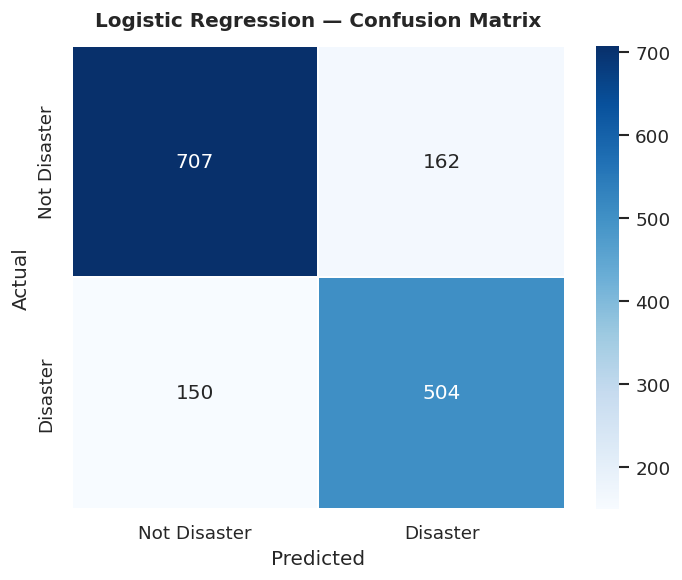

True Negatives  (correctly said not disaster) : 707
False Positives (said disaster, was not)      : 162
False Negatives (missed real disasters)       : 150
True Positives  (correctly caught disasters)  : 504


In [20]:

# CELL 17 — Confusion Matrix (Logistic Regression)

cm_lr = confusion_matrix(y_val, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disaster', 'Disaster'],
            yticklabels=['Not Disaster', 'Disaster'],
            linewidths=1, linecolor='white')
ax.set_title('Logistic Regression — Confusion Matrix',
             fontweight='bold', pad=12)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f"True Negatives  (correctly said not disaster) : {tn}")
print(f"False Positives (said disaster, was not)      : {fp}")
print(f"False Negatives (missed real disasters)       : {fn}")
print(f"True Positives  (correctly caught disasters)  : {tp}")

In [21]:

# CELL 18 — Multinomial Naive Bayes

from sklearn.naive_bayes import MultinomialNB
from scipy.sparse import hstack, csr_matrix
import numpy as np

# Naive Bayes requires non-negative values
# Our TF-IDF values are already non-negative
# But metadata features need to be scaled to similar range
# Simple fix — use only TF-IDF part for Naive Bayes

X_tr_nb  = X_tr[:, :5000]   # TF-IDF columns only
X_val_nb = X_val[:, :5000]

nb = MultinomialNB(alpha=0.1)
nb.fit(X_tr_nb, y_tr)
y_pred_nb = nb.predict(X_val_nb)


print("   NAIVE BAYES RESULTS")

print(classification_report(y_val, y_pred_nb,
      target_names=['Not Disaster', 'Disaster']))
print(f"F1 Score (macro): {f1_score(y_val, y_pred_nb, average='macro'):.4f}")

   NAIVE BAYES RESULTS
              precision    recall  f1-score   support

Not Disaster       0.80      0.91      0.85       869
    Disaster       0.85      0.70      0.77       654

    accuracy                           0.82      1523
   macro avg       0.83      0.80      0.81      1523
weighted avg       0.82      0.82      0.82      1523

F1 Score (macro): 0.8100


In [22]:

# CELL 19 — Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1      # use all CPU cores
)

rf.fit(X_tr, y_tr)
y_pred_rf = rf.predict(X_val)


print("   RANDOM FOREST RESULTS")

print(classification_report(y_val, y_pred_rf,
      target_names=['Not Disaster', 'Disaster']))
print(f"F1 Score (macro): {f1_score(y_val, y_pred_rf, average='macro'):.4f}")

   RANDOM FOREST RESULTS
              precision    recall  f1-score   support

Not Disaster       0.77      0.88      0.82       869
    Disaster       0.81      0.66      0.72       654

    accuracy                           0.78      1523
   macro avg       0.79      0.77      0.77      1523
weighted avg       0.79      0.78      0.78      1523

F1 Score (macro): 0.7735


Model                   F1 Disaster   F1 Not Dis   F1 Macro
Logistic Regression          0.7636       0.8192     0.7914
Naive Bayes                  0.7692       0.8508     0.8100
Random Forest                0.7234       0.8237     0.7735

 Best model: Naive Bayes (F1 macro: 0.8100)


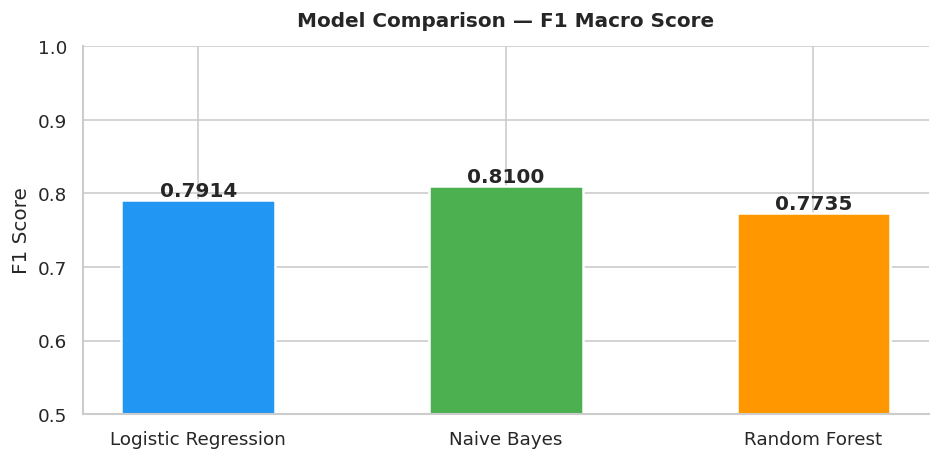

In [23]:

# CELL 20 — Model Comparison

models = {
    'Logistic Regression' : y_pred_lr,
    'Naive Bayes'         : y_pred_nb,
    'Random Forest'       : y_pred_rf
}


print(f"{'Model':<22} {'F1 Disaster':>12} {'F1 Not Dis':>12} {'F1 Macro':>10}")


results = {}
for name, preds in models.items():
    from sklearn.metrics import f1_score
    f1_dis     = f1_score(y_val, preds, pos_label=1)
    f1_not_dis = f1_score(y_val, preds, pos_label=0)
    f1_macro   = f1_score(y_val, preds, average='macro')
    results[name] = f1_macro
    print(f"{name:<22} {f1_dis:>12.4f} {f1_not_dis:>12.4f} {f1_macro:>10.4f}")


best_model = max(results, key=results.get)
print(f"\n Best model: {best_model} (F1 macro: {results[best_model]:.4f})")

# Visual comparison
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = ax.bar(results.keys(), results.values(), 
              color=colors, width=0.5,
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.4f}',
            ha='center', fontweight='bold')
ax.set_title('Model Comparison — F1 Macro Score',
             fontweight='bold', pad=12)
ax.set_ylabel('F1 Score')
ax.set_ylim(0.5, 1.0)
sns.despine()
plt.tight_layout()
plt.show()

In [24]:
# Cell 21 - looking at evaluation metrics properly
# i want to understand what precision and recall actually mean
# not just f1 score

from sklearn.metrics import precision_score, recall_score, f1_score

# using naive bayes since it was our best model
print("breaking down naive bayes performance")
print()

precision = precision_score(y_val, y_pred_nb)
recall    = recall_score(y_val, y_pred_nb)
f1        = f1_score(y_val, y_pred_nb)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print()
print("what these mean in plain english:")
print(f"  out of every tweet i said was disaster,")
print(f"  i was right {precision*100:.1f}% of the time  <- precision")
print(f"")
print(f"  out of every actual disaster tweet,")
print(f"  i caught {recall*100:.1f}% of them  <- recall")

breaking down naive bayes performance

Precision : 0.8487
Recall    : 0.7034
F1 Score  : 0.7692

what these mean in plain english:
  out of every tweet i said was disaster,
  i was right 84.9% of the time  <- precision

  out of every actual disaster tweet,
  i caught 70.3% of them  <- recall


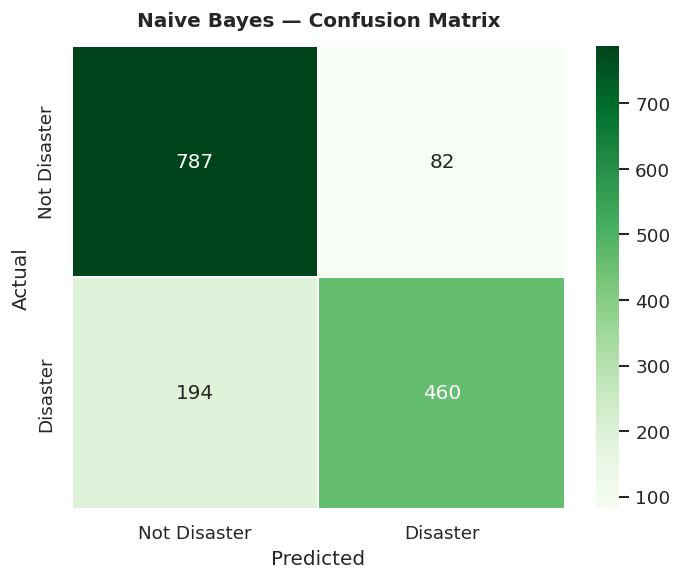

correctly said not disaster : 787
said disaster but was wrong : 82  <- false alarms
missed real disasters       : 194  <- most dangerous error
correctly caught disasters  : 460

total real disasters in val : 654
ones i caught               : 460 (70.3%)
ones i missed               : 194 (29.7%)


In [25]:
# Cell 22 - confusion matrix for naive bayes
# i noticed in logistic regression the bottom left number
# is false negatives - real disasters i missed
# want to see if naive bayes is better at catching those

cm_nb = confusion_matrix(y_val, y_pred_nb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Disaster', 'Disaster'],
            yticklabels=['Not Disaster', 'Disaster'],
            linewidths=1, linecolor='white')
ax.set_title('Naive Bayes — Confusion Matrix', 
             fontweight='bold', pad=12)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_nb.ravel()
print(f"correctly said not disaster : {tn}")
print(f"said disaster but was wrong : {fp}  <- false alarms")
print(f"missed real disasters       : {fn}  <- most dangerous error")
print(f"correctly caught disasters  : {tp}")
print()
print(f"total real disasters in val : {fn+tp}")
print(f"ones i caught               : {tp} ({tp/(fn+tp)*100:.1f}%)")
print(f"ones i missed               : {fn} ({fn/(fn+tp)*100:.1f}%)")

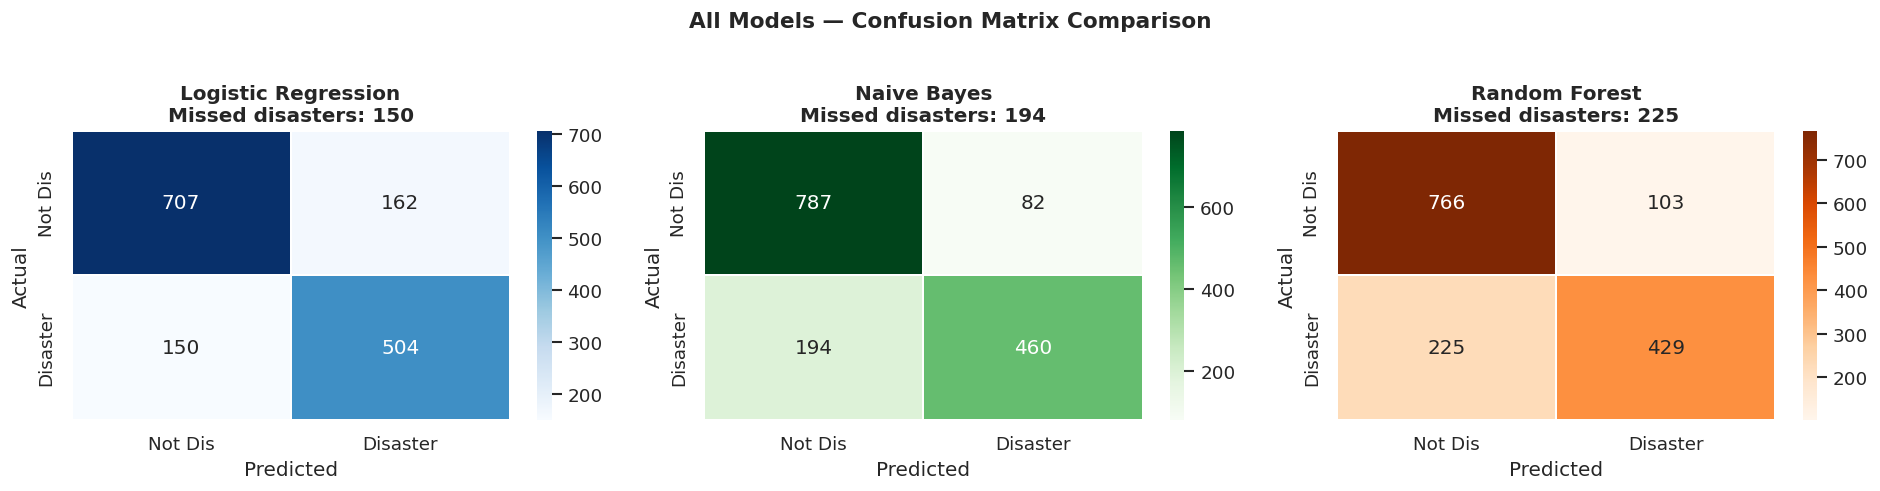

In [26]:
# Cell 23 - comparing all three confusion matrices side by side
# want to see visually which model makes fewer mistakes
# and what kind of mistakes each one makes

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

model_names = ['Logistic Regression', 'Naive Bayes', 'Random Forest']
predictions = [y_pred_lr, y_pred_nb, y_pred_rf]
cmaps       = ['Blues', 'Greens', 'Oranges']

for ax, name, preds, cmap in zip(axes, model_names, predictions, cmaps):
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Not Dis', 'Disaster'],
                yticklabels=['Not Dis', 'Disaster'],
                linewidths=1, linecolor='white', ax=ax)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nMissed disasters: {fn}', 
                 fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('All Models — Confusion Matrix Comparison', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# Cell 24 - looking at tweets my best model got wrong
# this is something i learned - always look at your mistakes
# it tells you what the model is confused about

# getting the validation tweets back
val_indices = y_val.index
val_tweets  = train.loc[val_indices, 'text'].reset_index(drop=True)
y_val_reset = y_val.reset_index(drop=True)

# naive bayes predictions on validation
# need to predict again to align indices properly
X_val_nb_reset = X_val[:, :5000]
nb_preds = y_pred_nb

errors = []
for i in range(len(nb_preds)):
    if nb_preds[i] != y_val_reset[i]:
        errors.append({
            'tweet'    : val_tweets[i],
            'actual'   : y_val_reset[i],
            'predicted': nb_preds[i]
        })

errors_df = pd.DataFrame(errors)

print(f"total mistakes naive bayes made: {len(errors_df)}")
print(f"out of {len(nb_preds)} validation tweets")
print()

# false negatives - real disasters model missed
fn_df = errors_df[errors_df['actual'] == 1]
print(f"=== real disasters i missed (false negatives): {len(fn_df)} ===")
for i, row in fn_df.head(5).iterrows():
    print(f"\n  [{i}] {row['tweet'][:100]}")

print()

# false positives - not disaster but model said disaster  
fp_df = errors_df[errors_df['actual'] == 0]
print(f"=== said disaster but was wrong (false positives): {len(fp_df)} ===")
for i, row in fp_df.head(5).iterrows():
    print(f"\n  [{i}] {row['tweet'][:100]}")

total mistakes naive bayes made: 276
out of 1523 validation tweets

=== real disasters i missed (false negatives): 194 ===

  [1] Hollywood Movie About Trapped Miners Released in Chile: 'The 33' Hollywood movie about trapped miner

  [2] Thu Aug 06 2015 01:20:32 GMT+0000 (UTC)
#millcityio #20150613
theramin sirens

  [3] I can't drown my demons they know how to swim

  [5] Dear @POTUS In the name of humanityI apologized to #Hiroshima Survivors.R u ready to do so?#Japan #n

  [6] 'It looks like a mudslide' poor thing! ?? #greatbritishbakeoff

=== said disaster but was wrong (false positives): 82 ===

  [0] @TheEconomist Step one: get that mass murderer's portrait off the yuan.

  [4] if firefighters acted like cops they'd drive around shooting a flamethrower at burning buildings

  [7] Ignition Knock (Detonation) Sensor-Senso Standard KS57 http://t.co/bzZdeDcthL http://t.co/OQJNUyIBxM

  [13] @TroySlaby22 slicker than an oil spill

  [18] Article by Michael Jackman at Metro Times Detroi

In [28]:
# Cell 25 - generating predictions on test data
# this is the actual kaggle submission part
# using naive bayes since it was best model

X_test_nb = X_test_full[:, :5000]
test_preds = nb.predict(X_test_nb)

print(f"test predictions generated: {len(test_preds)}")
print(f"predicted disaster     : {test_preds.sum()}")
print(f"predicted not disaster : {(test_preds==0).sum()}")
print()
print("sample predictions:")
for i in range(5):
    label = "DISASTER" if test_preds[i] == 1 else "not disaster"
    print(f"  tweet id {test['id'].iloc[i]} -> {label}")

test predictions generated: 3263
predicted disaster     : 1104
predicted not disaster : 2159

sample predictions:
  tweet id 0 -> DISASTER
  tweet id 2 -> not disaster
  tweet id 3 -> DISASTER
  tweet id 9 -> DISASTER
  tweet id 11 -> DISASTER


In [29]:
# Cell 26 - creating the submission file
# format has to match sample_submission.csv exactly
# just two columns - id and target

submission = pd.DataFrame({
    'id'    : test['id'],
    'target': test_preds
})

submission.to_csv('submission.csv', index=False)

print("submission.csv created successfully")
print(f"shape: {submission.shape}")
print()
print("first 10 rows:")
print(submission.head(10))
print()

# verify it matches the format kaggle expects
print("checking format matches sample submission...")
print(f"columns match : {list(submission.columns) == ['id', 'target']}")
print(f"row count match: {len(submission) == len(sub)}")
print("ready to submit to kaggle")

submission.csv created successfully
shape: (3263, 2)

first 10 rows:
   id  target
0   0       1
1   2       0
2   3       1
3   9       1
4  11       1
5  12       1
6  21       0
7  22       0
8  27       0
9  29       0

checking format matches sample submission...
columns match : True
row count match: True
ready to submit to kaggle


In [30]:
# Cell 27 - final summary of everything i built
# keeping this as a record of what worked and what didnt


print("  PROJECT SUMMARY")

print()
print("dataset")
print(f"  training tweets : 7613")
print(f"  test tweets     : 3263")
print(f"  class split     : 57% not disaster / 43% disaster")
print()
print("preprocessing")
print(f"  steps           : 7 (urls, html, lowercase,")
print(f"                    mentions, stopwords, tokenize, stem)")
print(f"  noise removed   : 43.8% of tokens")
print()
print("features")
print(f"  tfidf features  : 5000")
print(f"  metadata        : 3 (char, word, avg word len)")
print(f"  total           : 5003")
print()
print("model results on validation set")
print(f"  logistic regression : F1 = 0.7914")
print(f"  naive bayes         : F1 = 0.8100  <- best")
print(f"  random forest       : F1 = 0.7735")
print()
print("final model chosen : Naive Bayes")
print("submission file    : submission.csv")
print()
print("what i would try next to improve:")
print("  - lemmatization instead of stemming")
print("  - add url presence as binary feature")
print("  - try SVM which works well on text")
print("  - tune tfidf parameters")

  PROJECT SUMMARY

dataset
  training tweets : 7613
  test tweets     : 3263
  class split     : 57% not disaster / 43% disaster

preprocessing
  steps           : 7 (urls, html, lowercase,
                    mentions, stopwords, tokenize, stem)
  noise removed   : 43.8% of tokens

features
  tfidf features  : 5000
  metadata        : 3 (char, word, avg word len)
  total           : 5003

model results on validation set
  logistic regression : F1 = 0.7914
  naive bayes         : F1 = 0.8100  <- best
  random forest       : F1 = 0.7735

final model chosen : Naive Bayes
submission file    : submission.csv

what i would try next to improve:
  - lemmatization instead of stemming
  - add url presence as binary feature
  - try SVM which works well on text
  - tune tfidf parameters


In [31]:
import os
print(os.path.exists('/kaggle/working/submission.csv'))
print(pd.read_csv('/kaggle/working/submission.csv').shape)

True
(3263, 2)
